## 35. 搜索插入位置

给定一个排序数组和一个目标值，在数组中找到目标值，并返回其索引。如果目标值不存在于数组中，返回它将会被按顺序插入的位置。

请必须使用时间复杂度为 O(log n) 的算法。

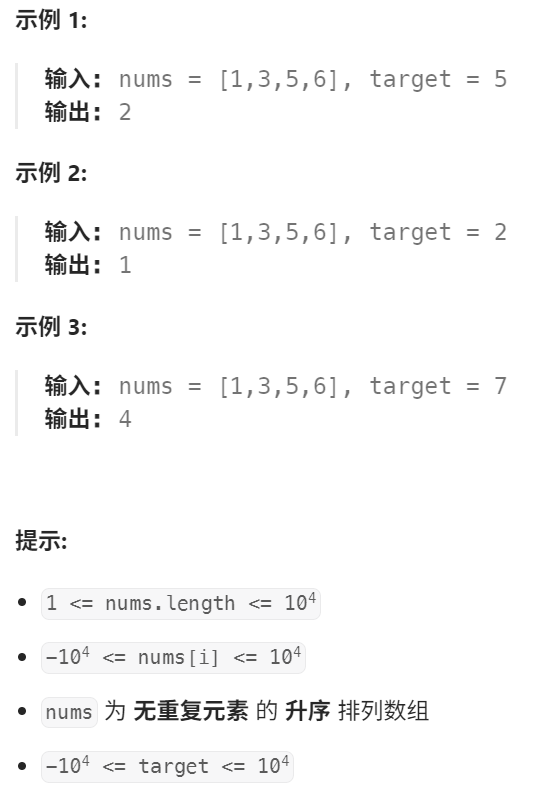

In [11]:
class Solution:
    def searchInsert(self, nums, target):
        left = 0
        right = len(nums) - 1
        while left <= right:
            middle = (left + right)//2
            if nums[middle] > target:
                right = middle - 1
            elif nums[middle] < target:
                left = middle + 1
            else:
                return middle
        return right + 1
nums = [1, 3, 5, 7]
target = 4
print(Solution().searchInsert(nums, target))

2


## 74. 搜索二维矩阵

给你一个满足下述两条属性的 m x n 整数矩阵：

每行中的整数从左到右按非严格递增顺序排列。

每行的第一个整数大于前一行的最后一个整数。

给你一个整数 target ，如果 target 在矩阵中，返回 true ；否则，返回 false 。

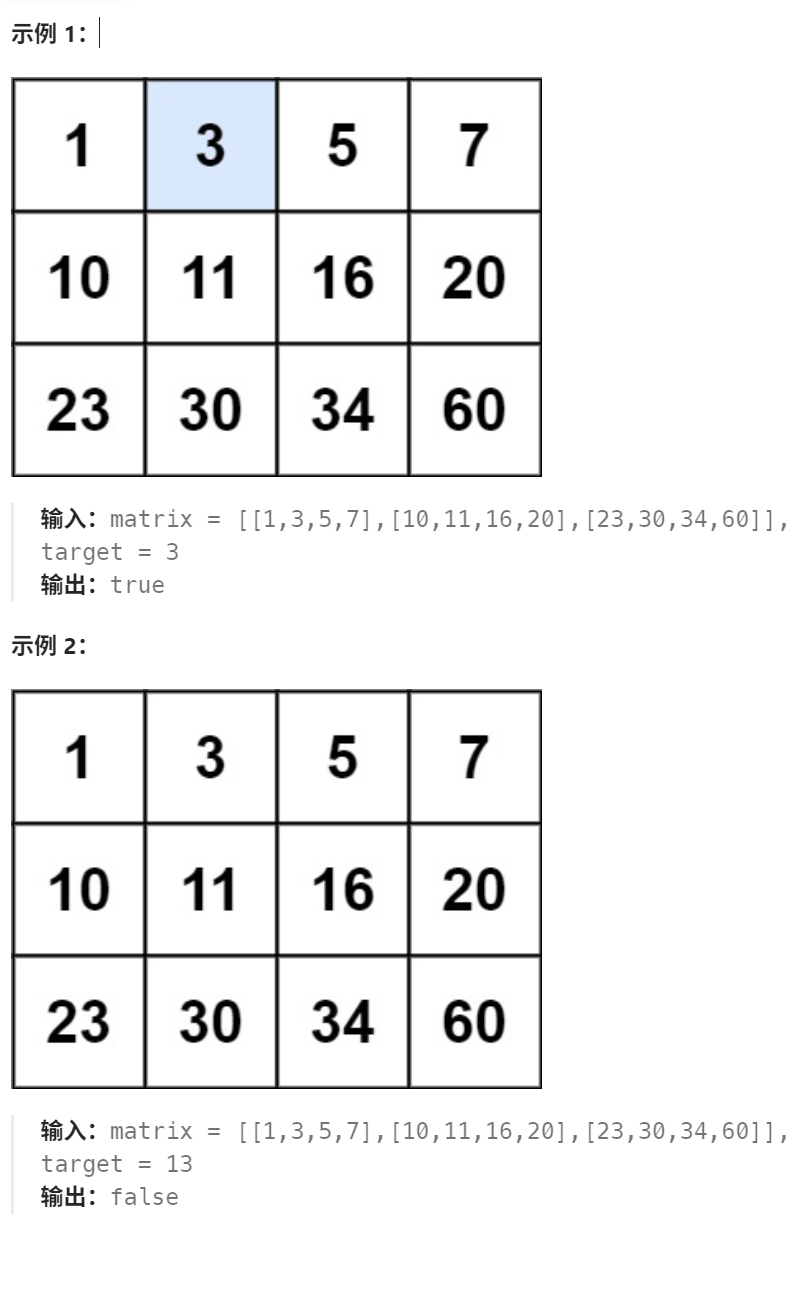


In [12]:
from typing import List

class Solution:
    def searchMatrix(self, matrix: List[List[int]], target: int) -> bool:
        
        m, n = len(matrix), len(matrix[0])

        # --- 第一步：二分查找确定目标行 ---
        top, bottom = 0, m - 1
        row = -1

        while top <= bottom:
            mid = (top + bottom) // 2

            if target > matrix[mid][-1]:
                top = mid + 1
            elif target < matrix[mid][0]:
                bottom = mid - 1
            else:
                row = mid
                break

        if row == -1:
            return False

        # --- 第二步：在该行进行二分查找 ---
        left, right = 0, n - 1

        while left <= right:
            mid = (left + right) // 2

            if matrix[row][mid] < target:
                left = mid + 1
            elif matrix[row][mid] > target:
                right = mid - 1
            else:
                return True

        return False

In [13]:
from typing import List

class Solution:
    def searchMatrix(self, matrix: List[List[int]], target: int) -> bool:
        
        m, n = len(matrix), len(matrix[0])

        # 把二维矩阵看作长度为 m*n 的一维有序数组
        left, right = 0, m * n - 1

        while left <= right:
            mid = (left + right) // 2

            # 将一维下标转换为二维坐标
            row = mid // n
            col = mid % n

            value = matrix[row][col]

            if value < target:
                left = mid + 1
            elif value > target:
                right = mid - 1
            else:
                return True

        return False

## 34. 在排序数组中查找元素的第一个和最后一个位置

给你一个按照非递减顺序排列的整数数组 nums，和一个目标值 target。请你找出给定目标值在数组中的开始位置和结束位置。

如果数组中不存在目标值 target，返回 [-1, -1]。

你必须设计并实现时间复杂度为 O(log n) 的算法解决此问题。

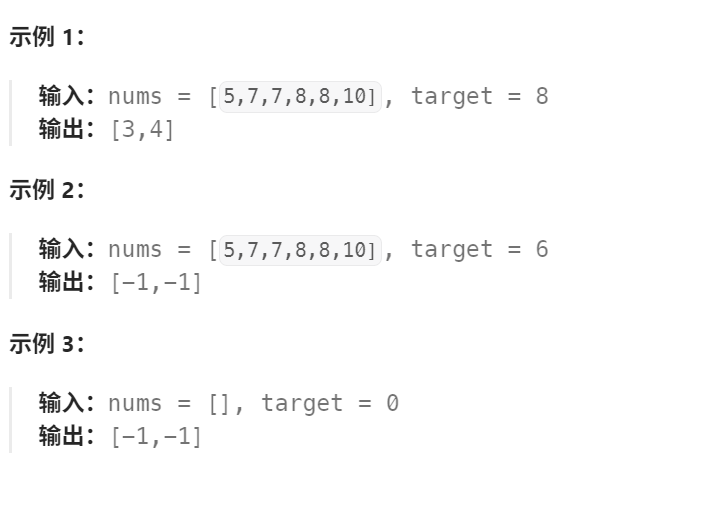

In [14]:
from typing import List

class Solution:
    def searchRange(self, nums: List[int], target: int) -> List[int]:

        def findLeft():
            left, right = 0, len(nums) - 1
            ans = -1

            while left <= right:
                mid = (left + right) // 2

                if  target <= nums[mid]:
                    right = mid - 1
                else:
                    left = mid + 1

                if target == nums[mid]:
                    ans = mid

            return ans


        def findRight():
            left, right = 0, len(nums) - 1
            ans = -1

            while left <= right:
                mid = (left + right) // 2

                if nums[mid] <= target:
                    left = mid + 1
                else:
                    right = mid - 1

                if nums[mid] == target:
                    ans = mid

            return ans


        return [findLeft(), findRight()]

本题属于边界二分问题

要求在一个按照非递减顺序排列的数组中找到目标值 `target` 的起始位置和结束位置，并且时间复杂度必须达到 (O(\log n))。由于数组已经有序，最合适的方法是使用 **二分查找**。然而普通的二分查找只能找到某一个 `target` 的位置，而不能保证找到的是最左或最右的出现位置。因此，本题的关键思想是 **通过两次二分查找分别确定左右边界**。

首先进行第一次二分查找，用于寻找目标值的 **最左位置**。在查找过程中，当 `nums[mid]` 大于或等于 `target` 时，将搜索区间向左收缩（`right = mid - 1`），因为即使当前位置等于 `target`，仍然可能在更左侧存在相同元素。当 `nums[mid]` 小于 `target` 时，则说明目标值一定在右侧区间（`left = mid + 1`）。通过这种方式不断缩小区间，当循环结束时即可得到 `target` 的最左位置。如果该位置的值不等于 `target`，说明数组中不存在该元素。

随后进行第二次二分查找，用于寻找目标值的 **最右位置**。这一次的策略与第一次相反：当 `nums[mid]` 小于或等于 `target` 时，将搜索区间向右移动（`left = mid + 1`），因为右侧仍然可能存在相同元素；当 `nums[mid]` 大于 `target` 时，则向左收缩区间（`right = mid - 1`）。最终循环结束时即可得到 `target` 的最右位置。通过两次二分查找即可确定目标值在数组中的完整区间。

时间复杂度为 (O(\log n))。原因是每一次二分查找都会将搜索区间缩小为原来的一半，因此查找过程最多执行 (\log n) 次迭代。本题需要执行两次二分查找，总复杂度为 (2 \times O(\log n))，在渐进复杂度分析中仍然记为 (O(\log n))。空间复杂度为 (O(1))，因为算法只使用了少量辅助变量，没有使用额外的数据结构。


## 33. 搜索旋转排序数组

整数数组 nums 按升序排列，数组中的值 互不相同 。

在传递给函数之前，nums 在预先未知的某个下标 k（0 <= k < nums.length）上进行了 向左旋转，使数组变为 [nums[k], nums[k+1], ..., nums[n-1], nums[0], nums[1], ..., nums[k-1]]（下标 从 0 开始 计数）。例如， [0,1,2,4,5,6,7] 下标 3 上向左旋转后可能变为 [4,5,6,7,0,1,2] 。

给你 旋转后 的数组 nums 和一个整数 target ，如果 nums 中存在这个目标值 target ，则返回它的下标，否则返回 -1 。

你必须设计一个时间复杂度为 O(log n) 的算法解决此问题。

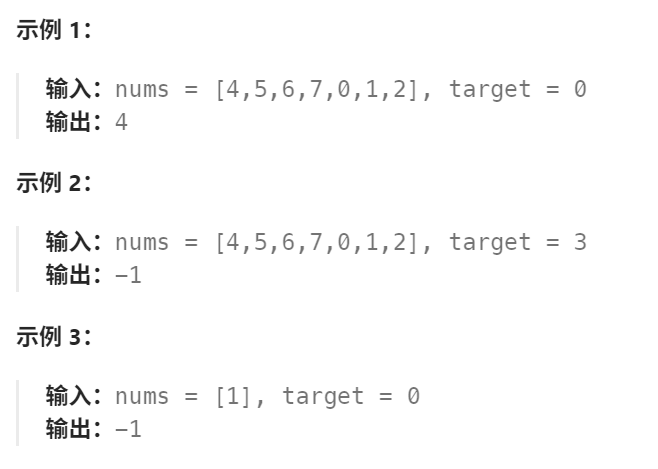

In [15]:
from typing import List

class Solution:
    def search(self, nums: List[int], target: int) -> int:
        left, right = 0, len(nums) - 1

        while left <= right:
            mid = (left + right) // 2

            # 找到了
            if nums[mid] == target:
                return mid

            # --- 判断哪一半是有序的 ---
            if nums[left] <= nums[mid]:
                # 左半部分有序

                if nums[left] <= target < nums[mid]:
                    # target 在左半部分
                    right = mid - 1
                else:
                    # 去右半部分找
                    left = mid + 1
            else:
                # 右半部分有序

                if nums[mid] < target <= nums[right]:
                    # target 在右半部分
                    left = mid + 1
                else:
                    # 去左半部分找
                    right = mid - 1

        return -1
nums = [6, 7, 8,  9, 10, 1, 2, 4]
target = 4
print(Solution().search(nums, target))

7


**核心思路**

普通二分查找依赖“整体有序”，但这里数组被旋转后：

👉 任意时刻，左右两部分一定有一部分是有序的

例如：

[4,5,6,7,0,1,2]

左半 [4,5,6,7] 有序

右半 [0,1,2] 有序

**算法策略**

每次二分时：
- 计算 mid
- 判断哪一边是“有序区间”
- 判断 target 是否在这个有序区间内
- 决定丢弃哪一半

**复杂度分析**

时间复杂度：
O(log n)（标准二分）

空间复杂度：
O(1)（原地操作）

---

## 153. 寻找旋转排序数组中的最小值

已知一个长度为 n 的数组，预先按照升序排列，经由 1 到 n 次 旋转 后，得到输入数组。例如，原数组 nums = [0,1,2,4,5,6,7] 在变化后可能得到：
若旋转 4 次，则可以得到 [4,5,6,7,0,1,2]
若旋转 7 次，则可以得到 [0,1,2,4,5,6,7]
注意，数组 [a[0], a[1], a[2], ..., a[n-1]] 旋转一次 的结果为数组 [a[n-1], a[0], a[1], a[2], ..., a[n-2]] 。

给你一个元素值 互不相同 的数组 nums ，它原来是一个升序排列的数组，并按上述情形进行了多次旋转。请你找出并返回数组中的 最小元素 。

你必须设计一个时间复杂度为 O(log n) 的算法解决此问题。

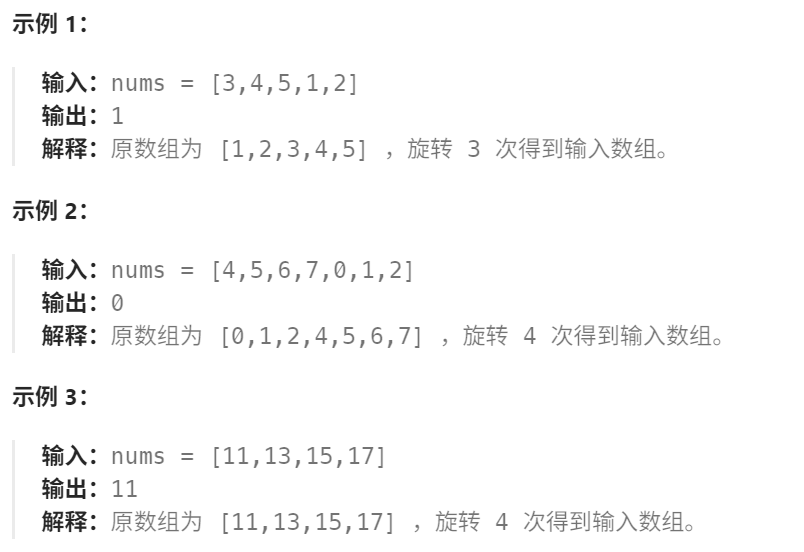

In [16]:
class Solution:
    def findMin(self, nums: List[int]) -> int:
        left, right = 0, len(nums)-1
        while left < right:
            mid = (left + right) // 2
            if nums[mid] > nums[right]:
                left = mid + 1
            else:
                right = mid
        return nums[right]

利用哪一侧有序来决定往哪边收缩

通过二分查找，每次比较 nums[mid] 和 nums[right]：如果 nums[mid] > nums[right]，说明最小值在右半区间；否则说明最小值在左半区间（包含 mid），不断缩小搜索区间，最终收敛到最小元素位置。

---

## 4. 寻找两个正序数组的中位数

给定两个大小分别为 m 和 n 的正序（从小到大）数组 nums1 和 nums2。请你找出并返回这两个正序数组的 中位数 。

算法的时间复杂度应该为 O(log (m+n)) 。

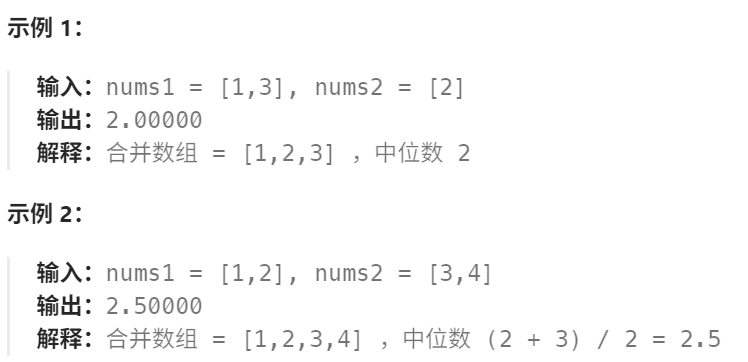

In [17]:
class Solution:
    def findMedianSortedArrays(self, nums1: List[int], nums2: List[int]) -> float:
        if len(nums1) > len(nums2):
            nums1, nums2 = nums2, nums1

        m, n = len(nums1), len(nums2)
        total_left = (m + n + 1) // 2
        lo, hi = 0, m

        while lo <= hi:
            i = (lo + hi) // 2
            j = total_left - i

            nums1_left_max  = nums1[i-1] if i > 0 else float('-inf')
            nums1_right_min = nums1[i]   if i < m else float('inf')
            nums2_left_max  = nums2[j-1] if j > 0 else float('-inf')
            nums2_right_min = nums2[j]   if j < n else float('inf')

            # ✅ 先判断两个条件同时合法
            if nums1_left_max <= nums2_right_min and nums2_left_max <= nums1_right_min:
                if (m + n) % 2 == 1:
                    return float(max(nums1_left_max, nums2_left_max))
                else:
                    left_max  = max(nums1_left_max, nums2_left_max)
                    right_min = min(nums1_right_min, nums2_right_min)
                    return (left_max + right_min) / 2
            # ① 不满足：nums1 左侧取多了 → i 左移
            elif nums1_left_max > nums2_right_min:
                hi = i - 1
            # ② 不满足：nums1 左侧取少了 → i 右移
            else:
                lo = i + 1

        return -1.0

nums1 = [2, 4, 6, 8]
nums2 = [9, 10, 11, 12]
print(Solution().findMedianSortedArrays(nums1, nums2))

8.5


“两个有序数组的第 k 小问题 + 二分划分”

通过在较短数组上进行二分查找，寻找一个划分位置，使得两个数组被分成左右两部分，并满足左半部分的最大值小于等于右半部分的最小值，同时保证左右两部分元素数量相等（或差1），从而可以在 O(log(min(m,n))) 时间内确定中位数。


中位数的本质是"分割"而非"排序"。
对于两个有序数组，我们的目标是找到一条"虚拟分割线"，使得分割线左侧的所有元素均 ≤ 右侧的所有元素，且左右两侧元素个数满足中位数的定义。由于两个数组各自有序，只需在较短的数组上做二分搜索，确定其分割点位置 i；另一个数组的分割点 j 由总长度约束自动决定（i + j = (m+n+1)//2）。每次二分将候选范围缩小一半，从而实现 O(log(min(m,n))) 的时间复杂度